# AIkenGPT G検定CPT：途中再開対応ノートブック

## 最初に読むこと

**通常は、次の「実験設定」セルだけを書き換えてください。**  
モデル定義・DataLoader・学習ループのセルは変更しません。

このノートブックが対応するのは、次の組み合わせです。

- AIkenGPT形式の `.pt` checkpoint
- GPT-2 tokenizer
- `uint16.bin`形式の連続トークンデータ

> QwenなどHugging Face形式のモデルは、このノートブックにはそのまま入れられません。別のCPTコードが必要です。

## 新しい実験を始める場合

1. `BASE_MODEL_NAME`：モデルを区別する短い名前
2. `BASE_CKPT`：学習を始めるモデル重みのパス
3. `DATASET_NAME`：データセットを区別する短い名前
4. `TRAIN_BIN`：学習データ（`.uint16.bin`）のパス
5. `OUT_ROOT`：結果を保存する親フォルダ
6. `NUM_EPOCHS`、`MAX_LR`：今回の学習条件

を設定し、`RESUME_MANIFEST`は空欄のままにします。

## 止まった学習を再開する場合

- `RESUME_MANIFEST`に、その実験フォルダ内の`resume_latest.pt`のパスを入れます。
- `TRAIN_BIN`は、**中断前と同じファイル**を指定してください。
- 新しい実験名や保存先を作り直さず、同じ実験フォルダに再開します。

再開時には、モデル・AdamW optimizer・DataLoaderの位置・乱数状態を読み込みます。

## 保存されるもの

```text
gkentei_cpt_step_000050.pt           # 評価・比較用のモデル重み
gkentei_cpt_optimizer_step_000100.pt # 厳密な再開用のoptimizer状態
resume_latest.pt                     # 再開に必要な情報
gkentei_cpt_final.pt                 # 学習完了時のモデル重み
```


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# optimizerファイルとresume_latest.ptの整合性を確認する

from google.colab import drive
from pathlib import Path
import torch

drive.mount(
    "/content/drive",
    force_remount=True,
)

OUT_DIR = Path(
    "/content/drive/MyDrive/"
    "aikengpt_gkentei_cpt_shuffled481000answer/"
    "base044000_lr5em06_ep2"
)

manifest_path = (
    OUT_DIR / "resume_latest.pt"
)

print("=" * 80)
print("実験フォルダ")
print(OUT_DIR)
print("exists:", OUT_DIR.exists())

print("\n" + "=" * 80)
print("フォルダ内のoptimizer関連ファイル")

optimizer_files = sorted(
    OUT_DIR.glob("*optimizer*")
)

if optimizer_files:
    for path in optimizer_files:
        size_gb = (
            path.stat().st_size
            / 1024**3
        )

        print(
            path.name,
            f"{size_gb:.2f} GB",
        )
else:
    print(
        "optimizer関連ファイルは"
        "見つかりませんでした。"
    )

print("\n" + "=" * 80)
print("一時ファイル")

temporary_files = sorted(
    OUT_DIR.glob("*.tmp")
)

if temporary_files:
    for path in temporary_files:
        size_gb = (
            path.stat().st_size
            / 1024**3
        )

        print(
            path.name,
            f"{size_gb:.2f} GB",
        )
else:
    print(
        ".tmpファイルはありません。"
    )

print("\n" + "=" * 80)
print("resume manifest")

print(
    "manifest path:",
    manifest_path,
)
print(
    "manifest exists:",
    manifest_path.exists(),
)

if not manifest_path.exists():
    raise FileNotFoundError(
        f"manifestがありません: {manifest_path}"
    )

manifest = torch.load(
    manifest_path,
    map_location="cpu",
    weights_only=False,
)

completed_steps = manifest.get(
    "completed_cpt_steps"
)

model_file_name = manifest.get(
    "model_file"
)

optimizer_file_name = manifest.get(
    "optimizer_file"
)

print(
    "checkpoint_type:",
    manifest.get("checkpoint_type"),
)
print(
    "completed steps:",
    completed_steps,
)
print(
    "model file:",
    model_file_name,
)
print(
    "optimizer file:",
    optimizer_file_name,
)

print("\n" + "=" * 80)
print("参照先の確認")

if model_file_name:
    model_path = (
        OUT_DIR / model_file_name
    )

    print(
        "model exists:",
        model_path.exists(),
    )

    if model_path.exists():
        print(
            "model size:",
            f"{model_path.stat().st_size / 1024**3:.2f} GB",
        )
else:
    print(
        "manifestにmodel_fileがありません。"
    )

if optimizer_file_name:
    optimizer_path = (
        OUT_DIR / optimizer_file_name
    )

    optimizer_exists = (
        optimizer_path.exists()
    )

    print(
        "optimizer path:",
        optimizer_path,
    )
    print(
        "optimizer exists:",
        optimizer_exists,
    )

    if optimizer_exists:
        optimizer_size_gb = (
            optimizer_path.stat().st_size
            / 1024**3
        )

        print(
            "optimizer size:",
            f"{optimizer_size_gb:.2f} GB",
        )

        if optimizer_size_gb < 15:
            print(
                "警告：optimizerファイルが"
                "想定より小さい可能性があります。"
            )
        else:
            print(
                "optimizerファイルは"
                "正常なサイズに見えます。"
            )
    else:
        print(
            "警告：resume_latest.ptが参照する"
            "optimizerファイルが存在しません。"
        )
else:
    print(
        "manifestにoptimizer_fileがありません。"
    )

Mounted at /content/drive
実験フォルダ
/content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2
exists: True

フォルダ内のoptimizer関連ファイル
optimizer関連ファイルは見つかりませんでした。

一時ファイル
.tmpファイルはありません。

resume manifest
manifest path: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2/resume_latest.pt
manifest exists: True
checkpoint_type: cpt_resume_manifest_v2
completed steps: 528
model file: gkentei_cpt_final.pt
optimizer file: gkentei_cpt_optimizer_step_000528.pt

参照先の確認
model exists: True
model size: 9.75 GB
optimizer path: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2/gkentei_cpt_optimizer_step_000528.pt
optimizer exists: False
警告：resume_latest.ptが参照するoptimizerファイルが存在しません。


In [ ]:
# NOTEBOOK_VERSION = "optimizer_split_v3"
print("Notebook version: optimizer_split_v3")

#@title 実験設定（原則、このセルだけを書き換える） { display-mode: "form" }

# ============================================================
# ① 新しい実験で変更する項目
# ============================================================

# 実験全体で到達したい合計epoch数。
# 再開時も、最終目標の総epoch数を指定する。
NUM_EPOCHS = 2 #@param {type:"integer"}

# 学習率の最大値。学習中はwarmup後にcosine decayする。
MAX_LR = 5e-6 #@param {type:"number"}
MIN_LR_RATIO = 0.1 #@param {type:"number"}

# 【モデルを変更するとき】
# モデルを識別する短い名前。保存フォルダ名に使われる。
# 例: "aikengpt_base_054000"
BASE_MODEL_NAME = "aikengpt_base_054000" #@param {type:"string"}

# 実際に学習を始めるAIkenGPT形式の .pt checkpoint のパス。
# Google Driveで対象ファイルを右クリック → 「パスをコピー」ではなく、
# Colabで見える /content/drive/MyDrive/... のパスを指定する。
BASE_CKPT = "/content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep1_0722/gkentei_cpt_final.pt" #@param {type:"string"}

# 【学習データを変更するとき】
# データセットを識別する短い名前。保存フォルダ名に使われる。
# 例: "gkentei_qa_481k_shuffled_v1"
DATASET_NAME = "gkentei_qa_481k_shuffled_v1" #@param {type:"string"}

# GPT-2 tokenizerで作成した .uint16.bin のパス。
# JSONLをそのまま指定しても学習できない。事前にトークン化した .bin を指定する。
TRAIN_BIN = "/content/drive/MyDrive/g_kentei_100_questions_together/answer_generation/answers_gpt2_eos_shuffled.uint16.bin" #@param {type:"string"}

# 【保存先を変更するとき】
# 各実験フォルダをまとめる親フォルダ。
# 実際の保存先は、この下にモデル名・データ名・LR・epoch数を含めて自動作成される。
OUT_ROOT = "/content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer" #@param {type:"string"}

# ============================================================
# ② 中断した学習を再開するときだけ変更する項目
# ============================================================

# 新しい実験なら空欄のまま。
# 再開時だけ、同じ実験フォルダ内の resume_latest.pt を指定する。
# 例: "/content/drive/MyDrive/.../resume_latest.pt"
RESUME_MANIFEST = "" #@param {type:"string"}

# True: 中断前の学習率スケジュールを維持する。
# False: 上で設定したNUM_EPOCHSに合わせて学習率スケジュールを引き直す。
PRESERVE_SAVED_LR_SCHEDULE = True #@param {type:"boolean"}

# ============================================================
# ③ 通常は変更しない項目
# ============================================================

# 評価用モデルを保存する間隔。
MODEL_SAVE_EVERY_STEPS = 50 #@param {type:"integer"}

# optimizer・DataLoader位置も含む再開用状態を保存する間隔。
OPTIMIZER_SAVE_EVERY_STEPS = 100 #@param {type:"integer"}
SAVE_OPTIMIZER_STATE = True #@param {type:"boolean"}

# Drive容量を節約するため、古いcheckpointは自動削除する。
KEEP_LAST_MODEL_CHECKPOINTS = 3 #@param {type:"integer"}
KEEP_ONLY_LATEST_OPTIMIZER = True #@param {type:"boolean"}

# モデルやGPU環境を変えない限り、通常は変更しない。
BATCH_SIZE = 4 #@param {type:"integer"}
GRAD_ACCUM = 128 #@param {type:"integer"}
SEQ_LEN = 2048 #@param {type:"integer"}
USE_COMPILE = True #@param {type:"boolean"}


Notebook version: optimizer_split_v3


In [ ]:
from dataclasses import dataclass
from pathlib import Path
import math
import os
import random
import time

import numpy as np
import torch

assert torch.cuda.is_available(), (
    "GPUランタイムにしてください。A100 80GB想定です。"
)
assert MODEL_SAVE_EVERY_STEPS >= 1
assert OPTIMIZER_SAVE_EVERY_STEPS >= 1
assert KEEP_LAST_MODEL_CHECKPOINTS >= 1


def lr_name(x):
    return (
        f"{x:.0e}"
        .replace("-", "m")
        .replace("+", "")
        .replace(".", "p")
    )


manual_resume_manifest = (
    Path(RESUME_MANIFEST)
    if RESUME_MANIFEST.strip()
    else None
)

if manual_resume_manifest is not None:
    assert manual_resume_manifest.exists(), (
        "再開用manifestがありません: "
        f"{manual_resume_manifest}"
    )
    OUT_DIR = manual_resume_manifest.parent
    RUN_NAME = OUT_DIR.name
else:
    RUN_NAME = (
        f"{BASE_MODEL_NAME}__{DATASET_NAME}_lr{lr_name(MAX_LR)}"
        f"_ep{NUM_EPOCHS}"
    )
    OUT_DIR = Path(OUT_ROOT) / RUN_NAME

OUT_DIR.mkdir(parents=True, exist_ok=True)

RESUME_MANIFEST_PATH = (
    manual_resume_manifest
    if manual_resume_manifest is not None
    else OUT_DIR / "resume_latest.pt"
)


@dataclass
class Config:
    train_token_path: str = TRAIN_BIN
    train_token_format: str = "bin"
    train_token_dtype: str = "uint16"

    base_checkpoint_path: str = BASE_CKPT
    checkpoint_dir: str = str(OUT_DIR)
    resume_manifest_path: str = (
        str(manual_resume_manifest)
        if manual_resume_manifest is not None
        else ""
    )

    batch_size: int = BATCH_SIZE
    gradient_accumulation_steps: int = GRAD_ACCUM
    num_epochs: int = NUM_EPOCHS
    input_sequence_length: int = SEQ_LEN
    max_sequence_length: int = SEQ_LEN

    embedding_dim: int = 2560
    hidden_dim: int = 10240
    num_attention_heads: int = 20
    layer_count: int = 30
    rope_theta: float = 1_000_000.0
    vocab_size: int = 50257

    max_learning_rate: float = MAX_LR
    min_learning_rate: float = MAX_LR * MIN_LR_RATIO
    warmup_steps: int = 0
    total_training_steps: int = 0

    weight_decay: float = 0.1
    max_grad_norm: float = 1.0
    device_type: str = "cuda"
    autocast_dtype: torch.dtype = torch.bfloat16
    use_torch_compile: bool = USE_COMPILE
    random_seed_value: int = 1337


config = Config()

random.seed(config.random_seed_value)
np.random.seed(config.random_seed_value)
torch.manual_seed(config.random_seed_value)
torch.cuda.manual_seed_all(config.random_seed_value)
torch.set_float32_matmul_precision("high")

assert Path(config.train_token_path).exists(), config.train_token_path

if manual_resume_manifest is None:
    assert Path(config.base_checkpoint_path).exists(), (
        config.base_checkpoint_path
    )

print("RUN_NAME:", RUN_NAME)
print("BASE_CKPT:", config.base_checkpoint_path)
print(
    "RESUME_MANIFEST:",
    config.resume_manifest_path or "<new run>",
)
print("TRAIN_BIN:", config.train_token_path)
print("OUT_DIR:", config.checkpoint_dir)
print("MAX_LR:", config.max_learning_rate)
print("MIN_LR:", config.min_learning_rate)
print("TARGET NUM_EPOCHS:", config.num_epochs)
print(
    "MODEL_SAVE_EVERY_STEPS:",
    MODEL_SAVE_EVERY_STEPS,
)
print(
    "OPTIMIZER_SAVE_EVERY_STEPS:",
    OPTIMIZER_SAVE_EVERY_STEPS,
)
print(
    "KEEP_LAST_MODEL_CHECKPOINTS:",
    KEEP_LAST_MODEL_CHECKPOINTS,
)
print(
    "SAVE_OPTIMIZER_STATE:",
    SAVE_OPTIMIZER_STATE,
)
print(
    "注意: AdamW optimizer stateは"
    "約20GBになる可能性があります。"
)
print(
    "保存中だけ新旧optimizerが同時に存在するため、"
    "追加の空き容量が必要です。"
)

RUN_NAME: base044000_lr5em06_ep2
BASE_CKPT: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep1_0722/gkentei_cpt_final.pt
RESUME_MANIFEST: <new run>
TRAIN_BIN: /content/drive/MyDrive/g_kentei_100_questions_together/answer_generation/answers_gpt2_eos_shuffled.uint16.bin
OUT_DIR: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2
MAX_LR: 5e-06
MIN_LR: 5.000000000000001e-07
TARGET NUM_EPOCHS: 2
MODEL_SAVE_EVERY_STEPS: 50
OPTIMIZER_SAVE_EVERY_STEPS: 100
KEEP_LAST_MODEL_CHECKPOINTS: 3
SAVE_OPTIMIZER_STATE: True
注意: AdamW optimizer stateは約20GBになる可能性があります。
保存中だけ新旧optimizerが同時に存在するため、追加の空き容量が必要です。


In [ ]:
def load_tokens(path, dtype="uint16"):
    return np.memmap(path, dtype=np.dtype(dtype), mode="r")

train_tokens = load_tokens(config.train_token_path, config.train_token_dtype)

tokens_per_step = (
    config.batch_size
    * config.gradient_accumulation_steps
    * config.input_sequence_length
)

steps_per_epoch = (int(train_tokens.size) - 1) // tokens_per_step
assert steps_per_epoch >= 1, "データが少なすぎます。batch/grad_accum/seq_lenを下げてください。"

# 再開時は、NUM_EPOCHSを「最終的に到達したい総epoch数」として扱う。
config.total_training_steps = steps_per_epoch * config.num_epochs
config.warmup_steps = max(1, round(config.total_training_steps * 0.03))
config.warmup_steps = min(config.warmup_steps, max(1, config.total_training_steps - 1))

class TokenLoader:
    def __init__(self, tokens, config):
        self.tokens = tokens
        self.config = config
        self.pos = 0

    def batch(self):
        need = self.config.batch_size * self.config.input_sequence_length
        if self.pos + need + 1 > self.tokens.size:
            self.pos = 0

        chunk = np.asarray(
            self.tokens[self.pos : self.pos + need + 1],
            dtype=np.int64,
        ).copy()

        self.pos += need

        x = torch.from_numpy(
            chunk[:-1].reshape(self.config.batch_size, self.config.input_sequence_length)
        ).to(config.device_type, non_blocking=True)

        y = torch.from_numpy(
            chunk[1:].reshape(self.config.batch_size, self.config.input_sequence_length)
        ).to(config.device_type, non_blocking=True)

        return x, y

    def state_dict(self):
        return {
            "pos": int(self.pos),
            "token_count": int(self.tokens.size),
        }

    def load_state_dict(self, state):
        saved_token_count = int(state.get("token_count", self.tokens.size))
        if saved_token_count != int(self.tokens.size):
            raise RuntimeError(
                "train token数がcheckpoint保存時と異なります: "
                f"saved={saved_token_count:,}, current={self.tokens.size:,}"
            )

        pos = int(state["pos"])
        if not 0 <= pos < int(self.tokens.size):
            raise RuntimeError(f"不正なloader positionです: {pos}")

        self.pos = pos

loader = TokenLoader(train_tokens, config)

print("train tokens:", f"{train_tokens.size:,}")
print("tokens/step:", f"{tokens_per_step:,}")
print("steps/epoch:", steps_per_epoch)
print("target total steps:", config.total_training_steps)
print("fresh-run warmup steps:", config.warmup_steps)


train tokens: 277,250,726
tokens/step: 1,048,576
steps/epoch: 264
target total steps: 528
fresh-run warmup steps: 16


In [ ]:
#@title モデル定義（触らない） { display-mode: "form" }
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding_table = nn.Embedding(config.vocab_size, config.embedding_dim)

    def forward(self, input_indices):
        return self.token_embedding_table(input_indices)

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=2048, rope_theta=1e6):
        super().__init__()

        inv_freq = 1.0 / (rope_theta ** (torch.arange(0, dim, 2, dtype=torch.float32) / dim))

        position_index = torch.arange(max_seq_len, dtype=torch.float32)
        freqs = torch.einsum('i,j->ij', position_index, inv_freq)

        freqs_complex = torch.polar(torch.ones_like(freqs), freqs)

        freqs_complex = freqs_complex.view(1, 1, max_seq_len, -1)
        self.register_buffer("freqs_complex", freqs_complex, persistent=False)

    def apply_rotary_emb(self, x, position_offset=0):
        sequence_length = x.size(2)

        x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))

        freqs = self.freqs_complex[:, :, position_offset:position_offset + sequence_length, :]

        x_rotated = x_complex * freqs

        x_out = torch.view_as_real(x_rotated).reshape_as(x)

        return x_out.to(x.dtype)

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_heads = config.num_attention_heads
        self.embed_dim = config.embedding_dim
        self.head_dim = self.embed_dim // self.num_heads

        self.query_fc = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.key_fc   = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.value_fc = nn.Linear(self.embed_dim, self.embed_dim, bias=False)

        self.rotary_emb = RotaryEmbedding(
            dim=self.head_dim,
            max_seq_len=config.max_sequence_length,
            rope_theta=config.rope_theta
        )

        self.output_projection = nn.Linear(self.embed_dim, self.embed_dim)

        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(
                config.max_sequence_length,
                config.max_sequence_length,
                dtype=torch.bool
            )),
            persistent=False
        )

        self.register_buffer("cache_k", None, persistent=False)
        self.register_buffer("cache_v", None, persistent=False)
        self.current_pos = 0

    def forward(self, x, use_cache=False):
        input_len = x.size(1)
        if use_cache is False:
            return self.forward_no_cache(x)
        elif use_cache is True and input_len > 1:
            return self.forward_prefill(x)
        elif use_cache is True and input_len == 1: # Hi scenario also starts with T==1
            return self.forward_cached_decoding(x)
        else:
            raise RuntimeError("Unexpected condition in MultiHeadAttention forward")

    def forward_no_cache(self, x):
        B, T, C = x.shape

        Q = self.query_fc(x)
        K = self.key_fc(x)
        V = self.value_fc(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        Q = self.rotary_emb.apply_rotary_emb(Q, position_offset=0)
        K = self.rotary_emb.apply_rotary_emb(K, position_offset=0)

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=None,
            is_causal=True
        )

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.output_projection(out)
        return out

    def forward_prefill(self, x):
        B, T, C = x.shape

        Q = self.query_fc(x)
        K = self.key_fc(x)
        V = self.value_fc(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        if self.cache_k is None:
            self.cache_k = torch.zeros(
                B, self.num_heads, self.config.max_sequence_length, self.head_dim,
                device=x.device, dtype=K.dtype
            )
            self.cache_v = torch.zeros(
                B, self.num_heads, self.config.max_sequence_length, self.head_dim,
                device=x.device, dtype=V.dtype
            )
            self.current_pos = 0

        Q = self.rotary_emb.apply_rotary_emb(Q, position_offset=self.current_pos)
        K = self.rotary_emb.apply_rotary_emb(K, position_offset=self.current_pos)

        if self.current_pos + T > self.config.max_sequence_length:
            raise RuntimeError("KV cache exceeded max_sequence_length")

        self.cache_k[:, :, self.current_pos:self.current_pos + T, :] = K
        self.cache_v[:, :, self.current_pos:self.current_pos + T, :] = V

        K = self.cache_k[:, :, :self.current_pos + T, :]
        V = self.cache_v[:, :, :self.current_pos + T, :]

        attn_mask = self.causal_mask[
            self.current_pos : self.current_pos + T,
            : self.current_pos + T
        ]

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_mask,
            is_causal=False
        )

        self.current_pos += T

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.output_projection(out)
        return out

    def forward_cached_decoding(self, x):
        B, T, C = x.shape
        assert T == 1, "cached decoding expects T==1"

        Q = self.query_fc(x)
        K = self.key_fc(x)
        V = self.value_fc(x)

        Q = Q.view(B, 1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, 1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, 1, self.num_heads, self.head_dim).transpose(1, 2)

        if self.cache_k is None:
            self.cache_k = torch.zeros(
                B, self.num_heads, self.config.max_sequence_length, self.head_dim,
                device=x.device, dtype=K.dtype
            )
            self.cache_v = torch.zeros(
                B, self.num_heads, self.config.max_sequence_length, self.head_dim,
                device=x.device, dtype=V.dtype
            )
            self.current_pos = 0

        if self.current_pos + 1 >= self.config.max_sequence_length:
            raise RuntimeError("KV cache exceeded max_sequence_length")

        Q = self.rotary_emb.apply_rotary_emb(Q, position_offset=self.current_pos)
        K = self.rotary_emb.apply_rotary_emb(K, position_offset=self.current_pos)

        self.cache_k[:, :, self.current_pos:self.current_pos + 1, :] = K
        self.cache_v[:, :, self.current_pos:self.current_pos + 1, :] = V

        K = self.cache_k[:, :, :self.current_pos + 1, :]
        V = self.cache_v[:, :, :self.current_pos + 1, :]

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=None,
            is_causal=False
        )

        self.current_pos += 1

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.output_projection(out)
        return out

    def reset_cache(self):
        self.cache_k = None
        self.cache_v = None
        self.current_pos = 0

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim, bias=False),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim, bias=False),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)
        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor, use_cache=False):
        normed_input = self.layer_norm1(input_tensor)
        attention_output = self.multihead_attention(normed_input, use_cache=use_cache)
        residual_attention = attention_output + input_tensor
        normed_attention = self.layer_norm2(residual_attention)
        feedforward_output = self.feed_forward(normed_attention)
        final_output = feedforward_output + residual_attention
        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        self.vocab_projection = nn.Linear(config.embedding_dim, config.vocab_size, bias=False)

    def forward(self, transformer_block_output):
        x = transformer_block_output
        normalized_output = self.output_norm(x)
        vocab_logits = self.vocab_projection(normalized_output)
        return vocab_logits

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_embedding_layer = TokenEmbedding(config=config)
        self.blocks = nn.ModuleList([TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(config=config)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, input_indices, target_indices, use_cache=False):
        token_embeddings = self.token_embedding_layer.forward(input_indices)

        x = token_embeddings
        for block in self.blocks:
            x = block(x, use_cache=use_cache)
        logits = self.vocab_projection(x)

        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits_flat = logits.view(batch_size * token_len, vocab_size)
        targets_flat = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits_flat, targets_flat)
        return logits, loss


In [ ]:
#@title CPT実行（モデルとoptimizerを分離保存） { display-mode: "form" }

def get_lr(
    step,
    schedule_total_steps,
    schedule_warmup_steps,
):
    if step < schedule_warmup_steps:
        return (
            config.max_learning_rate
            * (step + 1)
            / max(1, schedule_warmup_steps)
        )

    denom = max(
        1,
        schedule_total_steps
        - schedule_warmup_steps,
    )
    progress = min(
        max(
            (
                step
                - schedule_warmup_steps
            )
            / denom,
            0.0,
        ),
        1.0,
    )
    cosine = 0.5 * (
        1.0
        + math.cos(
            math.pi * progress
        )
    )

    return (
        config.min_learning_rate
        + cosine
        * (
            config.max_learning_rate
            - config.min_learning_rate
        )
    )


def unwrap_model(model):
    return getattr(
        model,
        "_orig_mod",
        model,
    )


def cleaned_model_state_dict(model):
    return {
        key.removeprefix("_orig_mod."): value
        for key, value
        in unwrap_model(model).state_dict().items()
    }


def atomic_torch_save(payload, path):
    # 一時ファイルへ保存し、完了後に本番名へ置き換える。
    path = Path(path)
    tmp_path = path.with_name(
        path.name + ".tmp"
    )

    if tmp_path.exists():
        tmp_path.unlink()

    torch.save(payload, tmp_path)
    os.sync()
    tmp_path.replace(path)
    os.sync()


def save_model_checkpoint(
    tag,
    completed_steps,
    model,
    loss_history,
):
    path = (
        Path(config.checkpoint_dir)
        / f"gkentei_cpt_{tag}.pt"
    )

    atomic_torch_save(
        {
            "checkpoint_type": (
                "model_only_cpt_experiment_v2"
            ),
            "completed_cpt_steps": int(
                completed_steps
            ),
            "model_state_dict": (
                cleaned_model_state_dict(model)
            ),
            "loss_history": loss_history,
            "config": vars(config),
            "base_checkpoint_path": (
                config.base_checkpoint_path
            ),
            "train_token_path": (
                config.train_token_path
            ),
        },
        path,
    )

    print(
        f"[saved model] {path} | "
        f"{path.stat().st_size / 1024**3:.2f} GB"
    )
    return path


def capture_rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "torch_cuda": (
            torch.cuda.get_rng_state_all()
        ),
    }


def restore_rng_state(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    torch.cuda.set_rng_state_all(
        state["torch_cuda"]
    )


def read_resume_manifest():
    if not RESUME_MANIFEST_PATH.exists():
        return None

    return torch.load(
        RESUME_MANIFEST_PATH,
        map_location="cpu",
        weights_only=False,
    )


def save_optimizer_and_manifest(
    completed_steps,
    model_checkpoint_path,
    optimizer,
    loader,
    lr_schedule_total_steps,
    lr_schedule_warmup_steps,
    loss_history,
):
    # optimizerは専用ファイルへ保存する。
    # loader位置・乱数状態・対応ファイル名は、
    # 小容量のresume_latest.ptへ保存する。
    output_dir = Path(config.checkpoint_dir)
    optimizer_path = (
        output_dir
        / (
            "gkentei_cpt_optimizer_step_"
            f"{completed_steps:06d}.pt"
        )
    )

    previous_manifest = read_resume_manifest()
    previous_optimizer_path = None

    if previous_manifest is not None:
        previous_name = previous_manifest.get(
            "optimizer_file"
        )
        if previous_name:
            previous_optimizer_path = (
                output_dir / previous_name
            )

    atomic_torch_save(
        {
            "checkpoint_type": (
                "cpt_optimizer_state_v2"
            ),
            "completed_cpt_steps": int(
                completed_steps
            ),
            "optimizer_state_dict": (
                optimizer.state_dict()
            ),
        },
        optimizer_path,
    )

    manifest = {
        "checkpoint_type": (
            "cpt_resume_manifest_v2"
        ),
        "completed_cpt_steps": int(
            completed_steps
        ),
        "model_file": Path(
            model_checkpoint_path
        ).name,
        "optimizer_file": optimizer_path.name,
        "loader_state_dict": (
            loader.state_dict()
        ),
        "rng_state": capture_rng_state(),
        "loss_history": loss_history,
        "lr_schedule_total_steps": int(
            lr_schedule_total_steps
        ),
        "lr_schedule_warmup_steps": int(
            lr_schedule_warmup_steps
        ),
        "planned_total_training_steps": int(
            config.total_training_steps
        ),
        "steps_per_epoch": int(
            steps_per_epoch
        ),
        "config": vars(config),
        "train_token_path": (
            config.train_token_path
        ),
    }

    # optimizerとmodelの保存後にmanifestを更新する。
    atomic_torch_save(
        manifest,
        RESUME_MANIFEST_PATH,
    )

    print(
        f"[saved optimizer] {optimizer_path} | "
        f"{optimizer_path.stat().st_size / 1024**3:.2f} GB"
    )
    print(
        "[updated manifest]",
        RESUME_MANIFEST_PATH,
    )

    # 新しいoptimizerとmanifestの保存成功後に、
    # 古いoptimizerだけを削除する。
    if (
        KEEP_ONLY_LATEST_OPTIMIZER
        and previous_optimizer_path
        is not None
        and previous_optimizer_path.exists()
        and previous_optimizer_path
        != optimizer_path
    ):
        previous_optimizer_path.unlink()
        print(
            "[removed old optimizer]",
            previous_optimizer_path,
        )

    return optimizer_path


def protected_model_name():
    manifest = read_resume_manifest()
    if manifest is None:
        return None
    return manifest.get("model_file")


def prune_periodic_model_checkpoints(
    keep_last,
):
    # periodic checkpointだけを整理する。
    # finalモデルとmanifest参照中のモデルは削除しない。
    output_dir = Path(config.checkpoint_dir)
    paths = sorted(
        output_dir.glob(
            "gkentei_cpt_step_*.pt"
        ),
        key=lambda path: path.name,
    )

    if len(paths) <= keep_last:
        return

    protected_name = protected_model_name()
    keep_names = {
        path.name
        for path in paths[-keep_last:]
    }

    if protected_name:
        keep_names.add(protected_name)

    for old_path in paths:
        if old_path.name in keep_names:
            continue

        old_path.unlink()
        print(
            "[removed old model]",
            old_path,
        )


def move_optimizer_state_to_device(
    optimizer,
    device,
):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(
                    device,
                    non_blocking=True,
                )


def validate_resume_config(saved_config):
    exact_keys = [
        "train_token_path",
        "batch_size",
        "gradient_accumulation_steps",
        "input_sequence_length",
        "embedding_dim",
        "hidden_dim",
        "num_attention_heads",
        "layer_count",
        "vocab_size",
    ]

    mismatches = []
    current = vars(config)

    for key in exact_keys:
        if (
            key in saved_config
            and saved_config[key]
            != current[key]
        ):
            mismatches.append(
                f"{key}: "
                f"saved={saved_config[key]!r}, "
                f"current={current[key]!r}"
            )

    if mismatches:
        raise RuntimeError(
            "optimizerを安全に再開できない"
            "設定差があります:\n- "
            + "\n- ".join(mismatches)
        )


device = torch.device(config.device_type)
model = GPT(config).to(device)

resume_manifest = None
start_step = 0
loss_history = []
lr_schedule_total_steps = (
    config.total_training_steps
)
lr_schedule_warmup_steps = (
    config.warmup_steps
)

if config.resume_manifest_path:
    print(
        "loading resume manifest:",
        config.resume_manifest_path,
    )
    resume_manifest = torch.load(
        config.resume_manifest_path,
        map_location="cpu",
        weights_only=False,
    )

    if (
        resume_manifest.get("checkpoint_type")
        != "cpt_resume_manifest_v2"
    ):
        raise RuntimeError(
            "対応していないmanifest形式です。"
        )

    validate_resume_config(
        resume_manifest.get("config", {})
    )

    output_dir = Path(config.checkpoint_dir)
    model_checkpoint_path = (
        output_dir
        / resume_manifest["model_file"]
    )
    optimizer_path = (
        output_dir
        / resume_manifest["optimizer_file"]
    )

    if not model_checkpoint_path.exists():
        raise FileNotFoundError(
            "manifestが参照するmodelがありません: "
            f"{model_checkpoint_path}"
        )

    if not optimizer_path.exists():
        raise FileNotFoundError(
            "manifestが参照するoptimizerがありません: "
            f"{optimizer_path}"
        )

    model_checkpoint = torch.load(
        model_checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    state = model_checkpoint[
        "model_state_dict"
    ]
    state = {
        key.removeprefix("_orig_mod."): value
        for key, value in state.items()
    }
    result = model.load_state_dict(
        state,
        strict=True,
    )

    start_step = int(
        resume_manifest["completed_cpt_steps"]
    )
    loss_history = list(
        resume_manifest.get(
            "loss_history",
            [],
        )
    )
    loader.load_state_dict(
        resume_manifest["loader_state_dict"]
    )

    if PRESERVE_SAVED_LR_SCHEDULE:
        lr_schedule_total_steps = int(
            resume_manifest[
                "lr_schedule_total_steps"
            ]
        )
        lr_schedule_warmup_steps = int(
            resume_manifest[
                "lr_schedule_warmup_steps"
            ]
        )

    print(
        "resumed model:",
        model_checkpoint_path,
    )
    print(
        "resumed optimizer:",
        optimizer_path,
    )
    print(
        "resumed completed steps:",
        start_step,
    )
    print(
        "resumed loader position:",
        loader.pos,
    )
else:
    model_checkpoint = torch.load(
        config.base_checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    state = (
        model_checkpoint["model_state_dict"]
        if "model_state_dict"
        in model_checkpoint
        else model_checkpoint
    )
    state = {
        key.removeprefix("_orig_mod."): value
        for key, value in state.items()
    }
    result = model.load_state_dict(
        state,
        strict=True,
    )
    optimizer_path = None

    print(
        "loaded base model:",
        config.base_checkpoint_path,
    )

print("missing:", result.missing_keys)
print("unexpected:", result.unexpected_keys)

del model_checkpoint
del state
torch.cuda.empty_cache()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.max_learning_rate,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=config.weight_decay,
)

if resume_manifest is not None:
    optimizer_checkpoint = torch.load(
        optimizer_path,
        map_location="cpu",
        weights_only=False,
    )

    if (
        optimizer_checkpoint.get(
            "checkpoint_type"
        )
        != "cpt_optimizer_state_v2"
    ):
        raise RuntimeError(
            "対応していないoptimizer形式です。"
        )

    optimizer.load_state_dict(
        optimizer_checkpoint[
            "optimizer_state_dict"
        ]
    )
    move_optimizer_state_to_device(
        optimizer,
        device,
    )

    del optimizer_checkpoint
    torch.cuda.empty_cache()

train_model = (
    torch.compile(model)
    if config.use_torch_compile
    else model
)
model.train()

# model、optimizer、compileの初期化後に
# 保存済み乱数状態を戻す。
if resume_manifest is not None:
    restore_rng_state(
        resume_manifest["rng_state"]
    )
    del resume_manifest
    torch.cuda.empty_cache()

if start_step > config.total_training_steps:
    raise RuntimeError(
        f"checkpointはstep {start_step}まで"
        "完了済みですが、現在のtarget total "
        f"stepsは{config.total_training_steps}です。"
        "NUM_EPOCHSを増やしてください。"
    )

print("start step:", start_step)
print(
    "target total steps:",
    config.total_training_steps,
)
print(
    "LR schedule total steps:",
    lr_schedule_total_steps,
)
print(
    "LR schedule warmup steps:",
    lr_schedule_warmup_steps,
)
print(
    "remaining optimizer steps:",
    config.total_training_steps
    - start_step,
)

if start_step == config.total_training_steps:
    print(
        "指定した総stepまで学習済みです。"
        "NUM_EPOCHSを増やすと追加学習できます。"
    )

started = time.time()
latest_optimizer_path = None

for step in range(
    start_step,
    config.total_training_steps,
):
    lr = get_lr(
        step,
        lr_schedule_total_steps,
        lr_schedule_warmup_steps,
    )

    for group in optimizer.param_groups:
        group["lr"] = lr

    optimizer.zero_grad(set_to_none=True)
    loss_sum = 0.0
    step_started = time.time()

    for _ in range(
        config.gradient_accumulation_steps
    ):
        x, y = loader.batch()

        with torch.autocast(
            device_type=config.device_type,
            dtype=config.autocast_dtype,
            enabled=True,
        ):
            _, loss = train_model(x, y)

        (
            loss
            / config.gradient_accumulation_steps
        ).backward()
        loss_sum += float(loss.item())

    grad_norm = (
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            config.max_grad_norm,
        )
    )

    optimizer.step()

    completed = step + 1
    mean_loss = (
        loss_sum
        / config.gradient_accumulation_steps
    )
    elapsed = time.time() - step_started
    tokens_per_second = (
        tokens_per_step / elapsed
        if elapsed > 0
        else 0.0
    )

    loss_history.append(
        {
            "step": completed,
            "lr": float(lr),
            "loss": float(mean_loss),
            "grad_norm": float(grad_norm),
            "loader_pos": int(loader.pos),
        }
    )

    print(
        f"step {completed:04d}/"
        f"{config.total_training_steps:04d} | "
        f"lr {lr:.2e} | "
        f"loss {mean_loss:.4f} | "
        f"grad {float(grad_norm):.3f} | "
        f"tok/s {tokens_per_second:,.0f}"
    )

    model_path_for_step = None

    if (
        completed
        % MODEL_SAVE_EVERY_STEPS
        == 0
    ):
        model_path_for_step = (
            save_model_checkpoint(
                f"step_{completed:06d}",
                completed,
                model,
                loss_history,
            )
        )

    if (
        SAVE_OPTIMIZER_STATE
        and completed
        % OPTIMIZER_SAVE_EVERY_STEPS
        == 0
    ):
        # optimizerと必ず同じstepのモデルを用意する。
        if model_path_for_step is None:
            model_path_for_step = (
                save_model_checkpoint(
                    f"step_{completed:06d}",
                    completed,
                    model,
                    loss_history,
                )
            )

        latest_optimizer_path = (
            save_optimizer_and_manifest(
                completed,
                model_path_for_step,
                optimizer,
                loader,
                lr_schedule_total_steps,
                lr_schedule_warmup_steps,
                loss_history,
            )
        )

    if model_path_for_step is not None:
        prune_periodic_model_checkpoints(
            KEEP_LAST_MODEL_CHECKPOINTS
        )

final_path = save_model_checkpoint(
    "final",
    config.total_training_steps,
    model,
    loss_history,
)

if SAVE_OPTIMIZER_STATE:
    latest_optimizer_path = (
        save_optimizer_and_manifest(
            config.total_training_steps,
            final_path,
            optimizer,
            loader,
            lr_schedule_total_steps,
            lr_schedule_warmup_steps,
            loss_history,
        )
    )

prune_periodic_model_checkpoints(
    KEEP_LAST_MODEL_CHECKPOINTS
)

print("done")
print(
    "elapsed sec:",
    f"{time.time() - started:,.1f}",
)
print("final model:", final_path)
print(
    "latest optimizer:",
    latest_optimizer_path,
)
print(
    "resume manifest:",
    RESUME_MANIFEST_PATH,
)

loaded base model: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep1_0722/gkentei_cpt_final.pt
missing: []
unexpected: []
start step: 0
target total steps: 528
LR schedule total steps: 528
LR schedule warmup steps: 16
remaining optimizer steps: 528


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:2212: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


step 0001/0528 | lr 3.13e-07 | loss 0.7902 | grad 0.068 | tok/s 11,707
step 0002/0528 | lr 6.25e-07 | loss 0.7919 | grad 0.070 | tok/s 17,052
step 0003/0528 | lr 9.38e-07 | loss 0.7944 | grad 0.069 | tok/s 17,043
step 0004/0528 | lr 1.25e-06 | loss 0.7938 | grad 0.069 | tok/s 17,047
step 0005/0528 | lr 1.56e-06 | loss 0.7908 | grad 0.070 | tok/s 17,046
step 0006/0528 | lr 1.88e-06 | loss 0.7856 | grad 0.070 | tok/s 17,048
step 0007/0528 | lr 2.19e-06 | loss 0.7887 | grad 0.070 | tok/s 17,050
step 0008/0528 | lr 2.50e-06 | loss 0.7950 | grad 0.070 | tok/s 17,047
step 0009/0528 | lr 2.81e-06 | loss 0.7821 | grad 0.071 | tok/s 17,047
step 0010/0528 | lr 3.13e-06 | loss 0.7886 | grad 0.071 | tok/s 17,041
step 0011/0528 | lr 3.44e-06 | loss 0.7812 | grad 0.072 | tok/s 17,034
step 0012/0528 | lr 3.75e-06 | loss 0.7920 | grad 0.073 | tok/s 17,036
step 0013/0528 | lr 4.06e-06 | loss 0.7944 | grad 0.071 | tok/s 17,033
step 0014/0528 | lr 4.38e-06 | loss 0.7924 | grad 0.071 | tok/s 17,040
step 0

Loss source: runtime loss_history
records: 528
first loss: 0.7902
final loss: 0.7127
minimum loss: 0.7034 at step 517


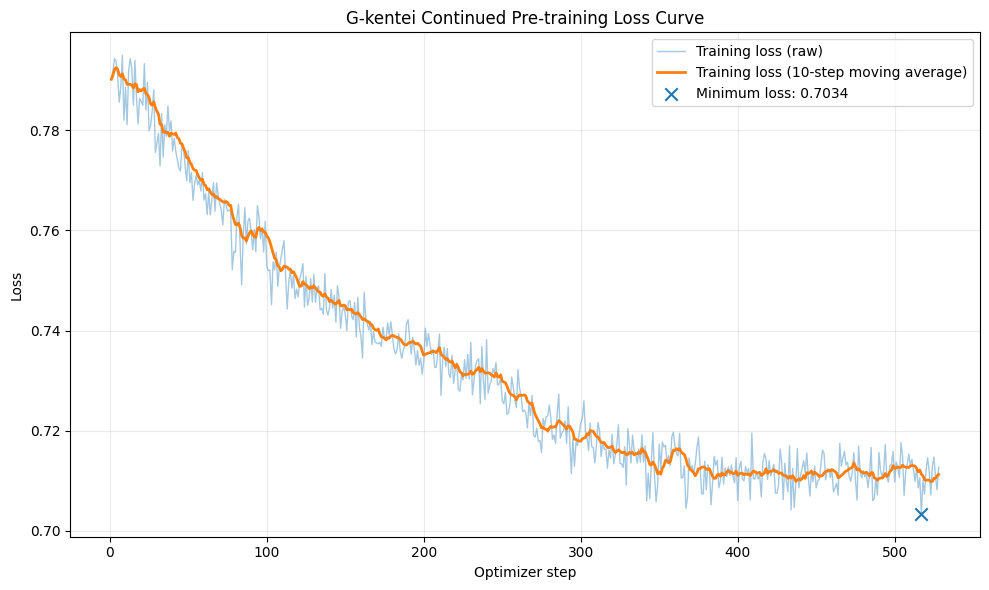

saved: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2/gkentei_cpt_loss_curve.png
saved: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2/gkentei_cpt_loss_history.csv


In [ ]:
#@title 学習完了後にLoss曲線を描画・保存する { display-mode: "form" }

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

# 移動平均に使うstep数
MOVING_AVERAGE_WINDOW = 10 #@param {type:"integer"}

# PNGとCSVをGoogle Driveへ保存する
SAVE_LOSS_FILES = True #@param {type:"boolean"}


def get_loss_history():
    """
    優先順位：
    1. 現在のランタイム上のloss_history
    2. gkentei_cpt_final.pt
    3. resume_latest.pt
    """
    runtime_history = globals().get(
        "loss_history"
    )

    if runtime_history:
        print(
            "Loss source: runtime loss_history"
        )
        return list(runtime_history)

    output_dir = Path(
        config.checkpoint_dir
    )

    final_checkpoint_path = (
        output_dir
        / "gkentei_cpt_final.pt"
    )

    if final_checkpoint_path.exists():
        checkpoint = torch.load(
            final_checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

        history = checkpoint.get(
            "loss_history",
            [],
        )

        del checkpoint

        if history:
            print(
                "Loss source:",
                final_checkpoint_path,
            )
            return list(history)

    resume_manifest_path = (
        output_dir
        / "resume_latest.pt"
    )

    if resume_manifest_path.exists():
        manifest = torch.load(
            resume_manifest_path,
            map_location="cpu",
            weights_only=False,
        )

        history = manifest.get(
            "loss_history",
            [],
        )

        del manifest

        if history:
            print(
                "Loss source:",
                resume_manifest_path,
            )
            return list(history)

    raise RuntimeError(
        "Loss履歴が見つかりません。"
        "学習セルを実行した後に、このセルを実行してください。"
    )


if MOVING_AVERAGE_WINDOW < 1:
    raise ValueError(
        "MOVING_AVERAGE_WINDOWは1以上にしてください。"
    )

history = get_loss_history()

loss_df = pd.DataFrame(
    history
)

required_columns = {
    "step",
    "loss",
}

missing_columns = (
    required_columns
    - set(loss_df.columns)
)

if missing_columns:
    raise RuntimeError(
        "Loss履歴に必要な列がありません: "
        f"{sorted(missing_columns)}"
    )

# 再開学習で同じstepが重複している場合は、
# 最後に記録された値を使用する
loss_df = (
    loss_df
    .sort_values("step")
    .drop_duplicates(
        subset=["step"],
        keep="last",
    )
    .reset_index(drop=True)
)

loss_df[
    "loss_moving_average"
] = (
    loss_df["loss"]
    .rolling(
        window=MOVING_AVERAGE_WINDOW,
        min_periods=1,
    )
    .mean()
)

minimum_row = loss_df.loc[
    loss_df["loss"].idxmin()
]

first_loss = float(
    loss_df.iloc[0]["loss"]
)
final_loss = float(
    loss_df.iloc[-1]["loss"]
)
minimum_loss = float(
    minimum_row["loss"]
)
minimum_step = int(
    minimum_row["step"]
)

print(
    f"records: {len(loss_df):,}"
)
print(
    f"first loss: {first_loss:.4f}"
)
print(
    f"final loss: {final_loss:.4f}"
)
print(
    f"minimum loss: {minimum_loss:.4f} "
    f"at step {minimum_step}"
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    loss_df["step"],
    loss_df["loss"],
    linewidth=1,
    alpha=0.4,
    label="Training loss (raw)",
)

plt.plot(
    loss_df["step"],
    loss_df[
        "loss_moving_average"
    ],
    linewidth=2,
    label=(
        f"Training loss "
        f"({MOVING_AVERAGE_WINDOW}-step "
        "moving average)"
    ),
)

plt.scatter(
    [minimum_step],
    [minimum_loss],
    marker="x",
    s=80,
    label=(
        f"Minimum loss: "
        f"{minimum_loss:.4f}"
    ),
)

plt.xlabel(
    "Optimizer step"
)
plt.ylabel(
    "Loss"
)
plt.title(
    "G-kentei Continued Pre-training Loss Curve"
)
plt.grid(
    True,
    alpha=0.25,
)
plt.legend()
plt.tight_layout()

output_dir = Path(
    config.checkpoint_dir
)

png_path = (
    output_dir
    / "gkentei_cpt_loss_curve.png"
)

csv_path = (
    output_dir
    / "gkentei_cpt_loss_history.csv"
)

if SAVE_LOSS_FILES:
    plt.savefig(
        png_path,
        dpi=200,
        bbox_inches="tight",
    )

    loss_df.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig",
    )

plt.show()

if SAVE_LOSS_FILES:
    print(
        "saved:",
        png_path,
    )
    print(
        "saved:",
        csv_path,
    )

In [ ]:
# =========================================================
# 直近CPT checkpointで生成テスト
# =========================================================

!pip -q install tiktoken

from pathlib import Path

import tiktoken
import torch

enc = tiktoken.get_encoding("gpt2")

output_dir = Path(config.checkpoint_dir)
final_checkpoint = (
    output_dir
    / "gkentei_cpt_final.pt"
)

if final_checkpoint.exists():
    TEST_CKPT = final_checkpoint
else:
    periodic_checkpoints = sorted(
        output_dir.glob(
            "gkentei_cpt_step_*.pt"
        ),
        key=lambda path: path.name,
    )
    assert periodic_checkpoints, (
        "model checkpointが見つかりません: "
        f"{config.checkpoint_dir}"
    )
    TEST_CKPT = periodic_checkpoints[-1]

print("TEST_CKPT:", TEST_CKPT)

device = torch.device(config.device_type)
model = GPT(config).to(device)

checkpoint = torch.load(
    TEST_CKPT,
    map_location="cpu",
    weights_only=False,
)
state = {
    key.removeprefix("_orig_mod."): value
    for key, value
    in checkpoint["model_state_dict"].items()
}
model.load_state_dict(
    state,
    strict=True,
)

del checkpoint
del state
model.eval()
torch.cuda.empty_cache()


@torch.no_grad()
def generate(
    prompt,
    max_new_tokens=160,
    temperature=0.8,
):
    ids = enc.encode(prompt)
    x = torch.tensor(
        ids,
        device=device,
    ).unsqueeze(0)

    for _ in range(max_new_tokens):
        x_in = x[
            :,
            -config.max_sequence_length:,
        ]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            logits, _ = model(
                x_in,
                None,
            )

        logits = (
            logits[:, -1, :].float()
            / temperature
        )
        probabilities = torch.softmax(
            logits,
            dim=-1,
        )
        next_id = torch.multinomial(
            probabilities,
            num_samples=1,
        )

        x = torch.cat(
            [x, next_id],
            dim=1,
        )

        if next_id.item() == 50256:
            break

    return enc.decode(x[0].tolist())


prompts = [
    "機械学習における過学習とは、",
    "シンギュラリティとは、",
    "AIという言葉が初めて使われたのは",
    "ダートマス会議とは、",
    "G検定におけるフレーム問題とは、",
]

for index, prompt in enumerate(
    prompts,
    1,
):
    print("=" * 80)
    print(f"[Prompt {index}] {prompt}")
    print("-" * 80)
    print(generate(prompt))

TEST_CKPT: /content/drive/MyDrive/aikengpt_gkentei_cpt_shuffled481000answer/base044000_lr5em06_ep2/gkentei_cpt_final.pt
[Prompt 1] 機械学習における過学習とは、
--------------------------------------------------------------------------------
機械学習における過学習とは、モデルが訓練データの特徴量に対して過度に適合し、汎化性能が低下する現象です。モデルは訓練データのパターンを正しく捉えようとしますが、その訓練データに対して正解ラベルが極端に少ない、あるいは訓練データに過度に適合した結果
[Prompt 2] シンギュラリティとは、
--------------------------------------------------------------------------------
シンギュラリティとは、機械やシステムが人間の限界を超えて急速に賢くなることを指し、AIは膨大なデータと高度なアルゴリズムを用いて需要予測や価格設定といった複雑な制御を行うため、全体的な性能とコストが大幅に拡大すると予想されます。<|endoftext|>
[Prompt 3] AIという言葉が初めて使われたのは
--------------------------------------------------------------------------------
AIという言葉が初めて使われたのは、1970年代初頭の自動車販売調査において、「自動車の生産がすでに中国国内に依存している」ことを示す用語として初めて登場したのが始まりです。したがって、汎用的な”International”（国際的）な感覚としての”International”は、英語の感情
[Prompt 4] ダートマス会議とは、
--------------------------------------------------------------------------------
ダートマス会議とは、20世紀後半にパーソナルコンピュータが実現した高度な情報処理技術を、参加者がその利便性と経済性

学習完了後に自動でランタイムを切断するセルです。

ファイルのアップロードに時間がかかる場合、ファイルが消えてしまうので注意してください。

In [1]:
# import time
# from google.colab import runtime

# print("学習完了。10秒後にランタイムを切断します。")
# time.sleep(10)
# runtime.unassign()